## 45 Days ML Journey - Day07
### Linear Regression

In [1]:
# import necessary libs.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### Creating a sample vector

In [2]:
X = np.random.rand(100, 1) * 2
y = 4 + 3 * X + np.random.rand(100, 1)

### Plotting the above data ponits.

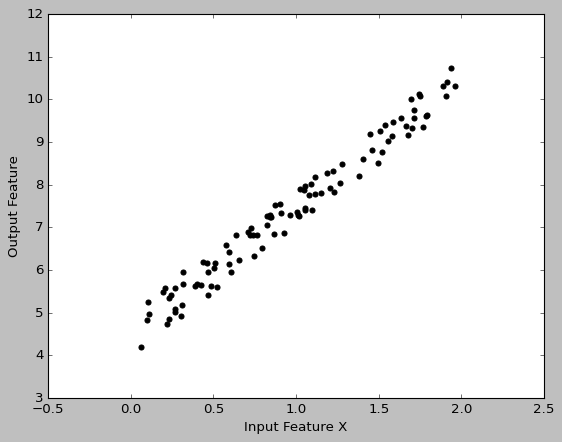

In [3]:
plt.style.use('classic')
plt.scatter(X, y, color="black", marker="o")
plt.xlabel("Input Feature X")
plt.ylabel("Output Feature")
plt.show()

To calculate the coefficients of regression, the formula for calculating the closed form solution is given below.
<br/>
[[X_transpose . X ]_inverse] . X_transpose . y

In [4]:
X_b = np.c_[ (np.ones((100, 1))), X ]
betas = np.linalg.inv( X_b.T.dot( X_b ) ).dot(X_b.T).dot(y)

After running above given code segment, the **betas** array contains the values for both (regression coefficients and intercept).
<br/>
**betas[0]** represents the value of intercept (bias) term. whereas the rest of the values in the **betas** array represents the coefficient term.

In [5]:
print("Value of intercept (bias) term : ", betas[0])
print("Value of coefficients are : ", betas[1])

Value of intercept (bias) term :  [4.51513566]
Value of coefficients are :  [2.98645317]


### Plotting the regression line using `bias` & `coefficient` terms.

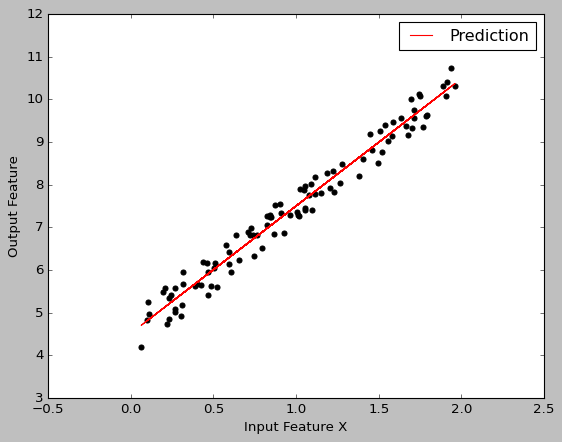

In [6]:
plt.style.use('classic')
plt.scatter(X, y, color="black", marker="o")
plt.plot(X, ( betas[1]*X + betas[0] ), color="red", label="Prediction")
plt.xlabel("Input Feature X")
plt.ylabel("Output Feature")
plt.legend()
plt.show()

Calculating the exact same terms i.e., `intercept` and `coefficient` using `sklearn.linear_model.LinearRegression` class. and comparing it with my calcuated values.

In [7]:
simple_linear_regression = LinearRegression()
simple_linear_regression.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
print(
    "intercept value (sklearn class) : ", simple_linear_regression.intercept_,
    "\ncoefficient value (sklearn class) : ", simple_linear_regression.coef_
)

intercept value (sklearn class) :  [4.51513566] 
coefficient value (sklearn class) :  [[2.98645317]]


In [9]:
print("Value of intercept (manually calculated) : ", betas[0])
print("Value of coefficients (manually calculated) : ", betas[1])

Value of intercept (manually calculated) :  [4.51513566]
Value of coefficients (manually calculated) :  [2.98645317]


The `LinearRegression` class of `sklearn` based on the `scipy.linalg.lstsq()` function, which we can call directly.

In [10]:
import scipy

best_betas, residuals, rank, s = scipy.linalg.lstsq( X_b, y,)

In [11]:
best_betas

array([[4.51513566],
       [2.98645317]])